# 02 — Sleep duration and variability vs cycle length

Reproduces **Figure 2** (cycle length and deviation × mean sleep duration
and × sleep duration log-variance) and supplementary figure
**S5** (sleep / workout-load × age and BMI).

All four Fig 2 panels are GEEs on the cycle table with control terms +
seasonal terms + all sleep / workout covariates. The within-subject
contrast (the OR for the deviation panels at sleep 6 vs 8 hours) refits the
model on the subset of users who logged cycles in both bins.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from menstrual_cycle_analysis import (
    CycleLengthAnalyses,
    StatisticalPredictionHandler,
    load_paper_data,
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Load data

In [2]:
day_df, CBM = load_paper_data()

CBM.add_sleep_behaviors('user')
CBM.add_sleep_behaviors('cycle')
CBM.add_workout_behaviors('user')
CBM.add_workout_behaviors('cycle')

cla = CycleLengthAnalyses(CBM=CBM)

print(f"Users:  {CBM.tables['user'].shape[0]:,}")
print(f"Cycles: {CBM.tables['cycle'].shape[0]:,}")

/Users/alex/Documents/Research/WHOOP/menstrual_cycle_physiology_sleep_whoop/menstrual_cycle_analysis/stats/circular.py:18: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.circmean(2 * np.pi * x / 24, nan_policy="omit") / (2 * np.pi) * 24


/Users/alex/Documents/Research/WHOOP/menstrual_cycle_physiology_sleep_whoop/menstrual_cycle_analysis/stats/circular.py:23: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.circvar(2 * np.pi * x / 24, nan_policy="omit")


Users:  2,596
Cycles: 42,759


## Figure 2 — cycle length and deviation by sleep duration and variability

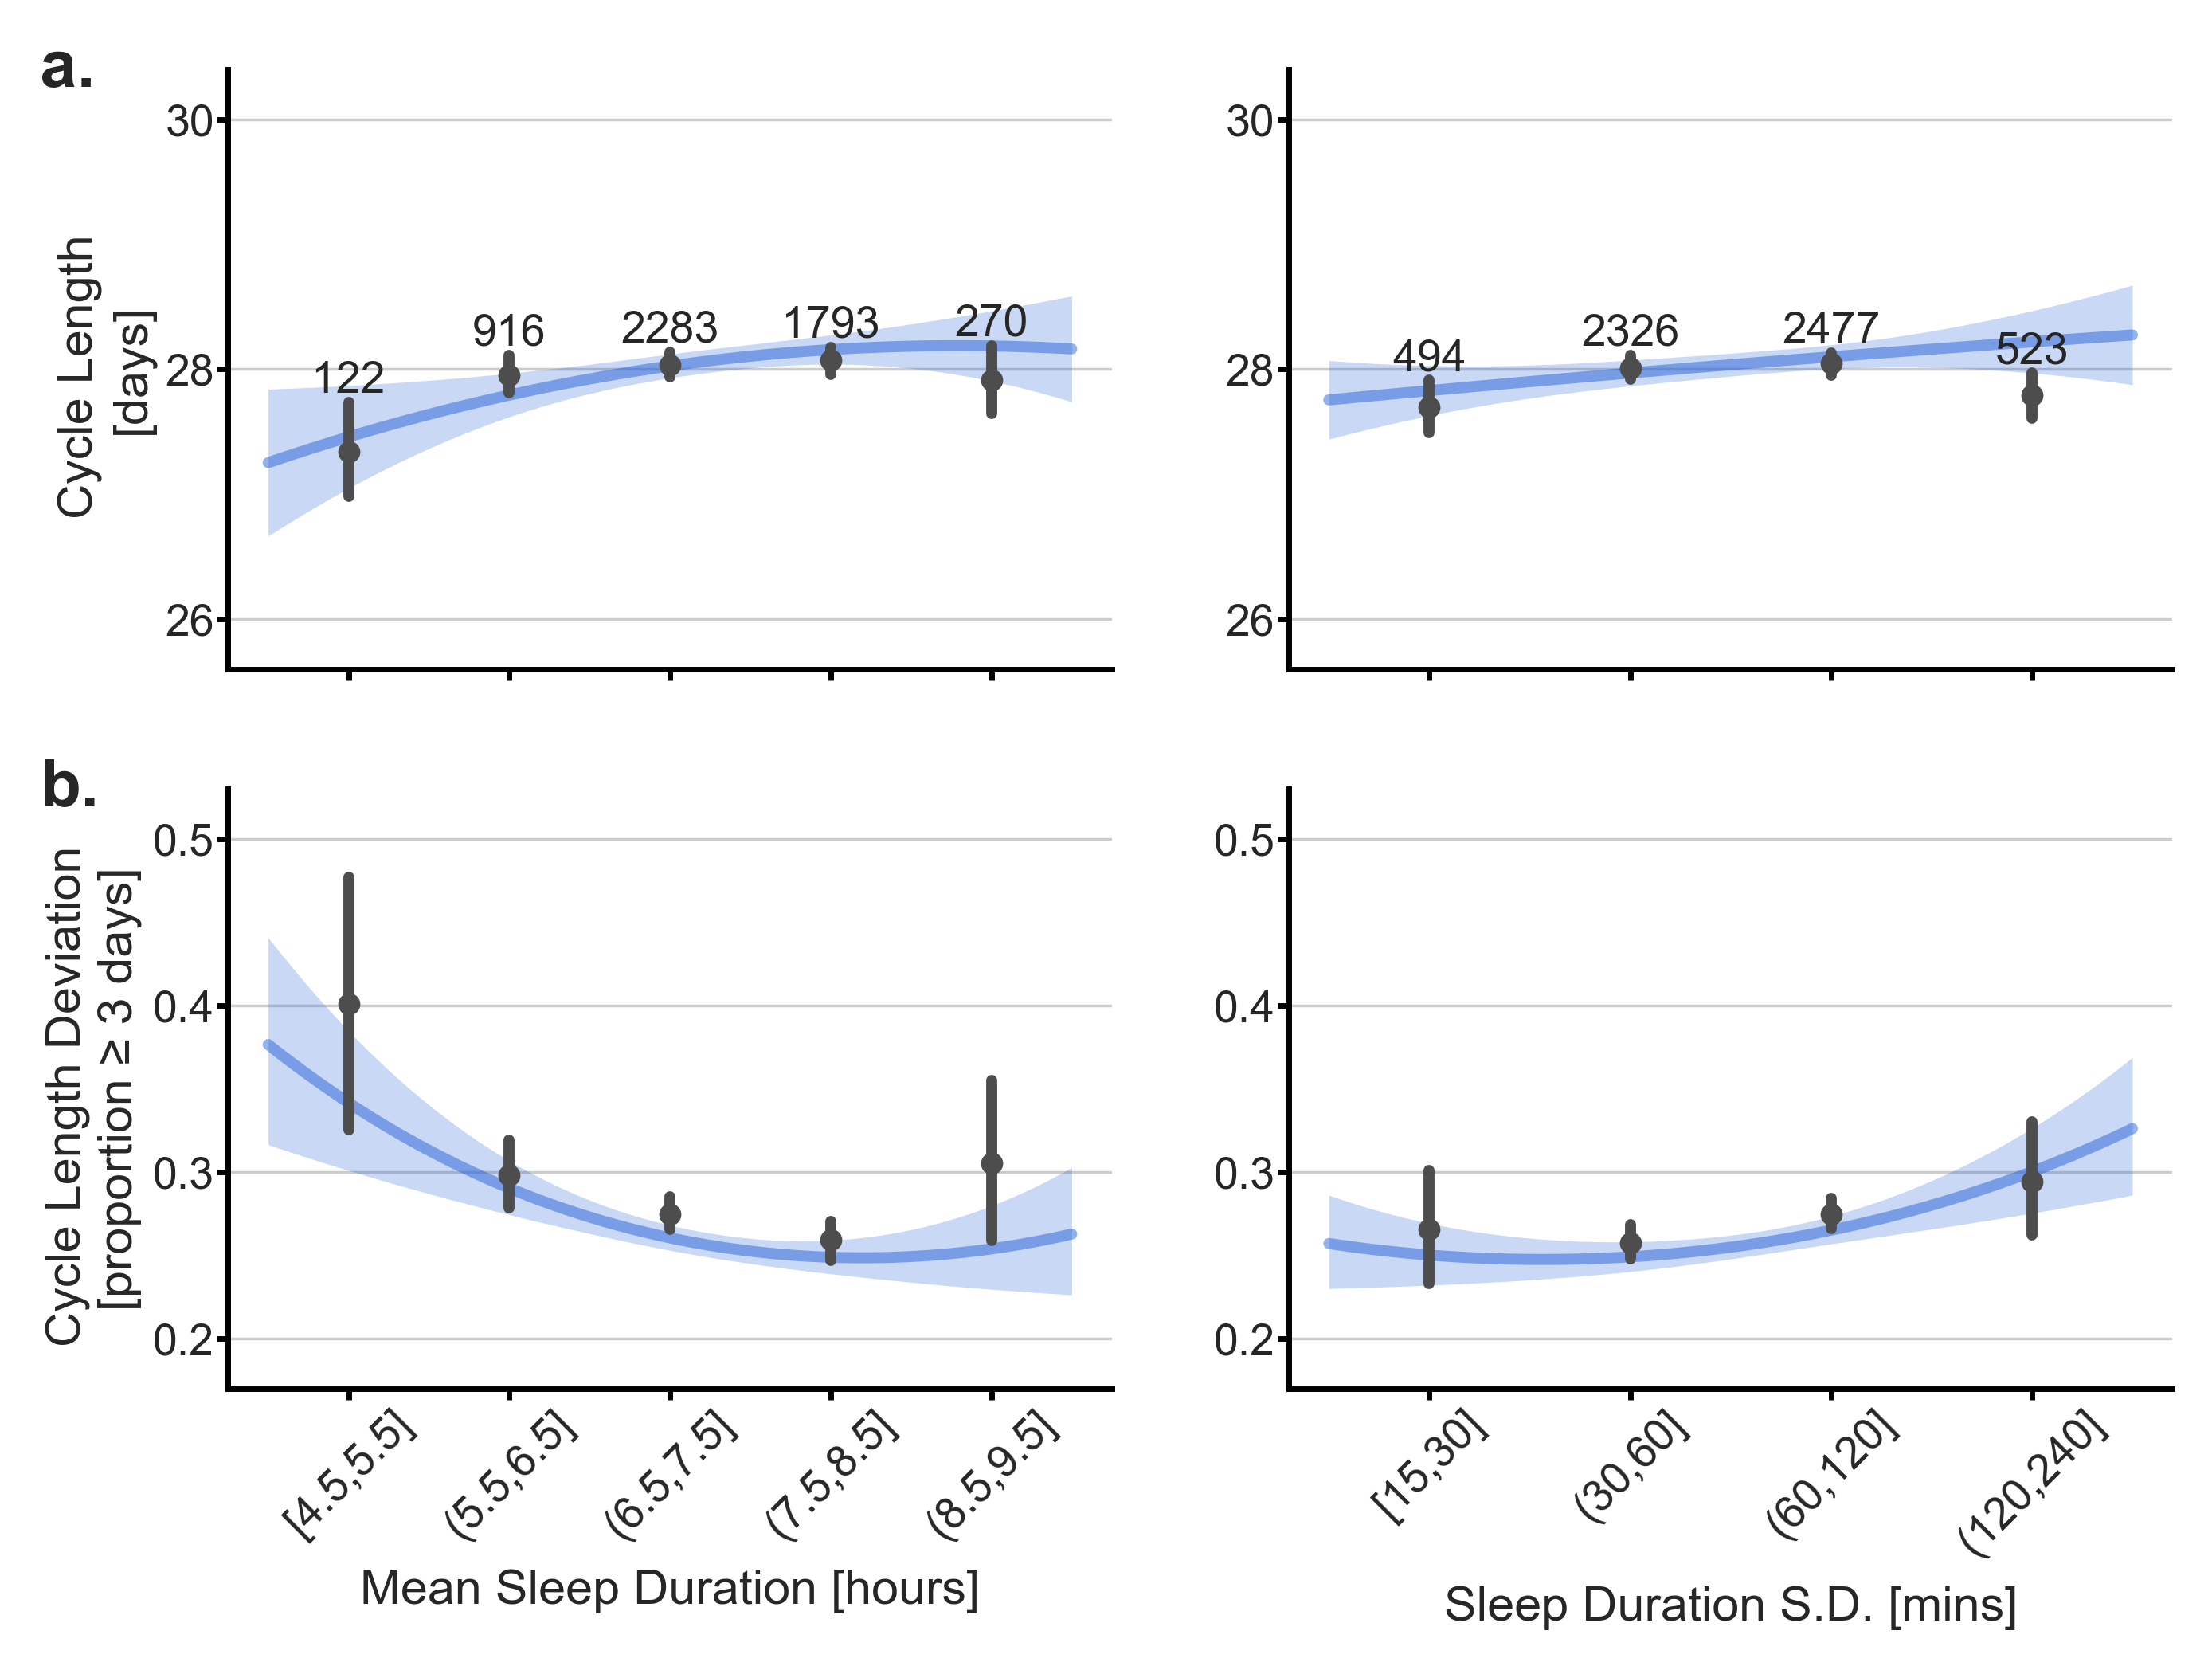

In [3]:
cla._setup_layout_params(dict(w_spacing=0.3, h_spacing=0.3))
cla.cl_x_sleep_plots(save_fig=False)
plt.show()

### Stats — sleep duration

In [4]:
panel = 'cl_mean_sl_dur'
m = cla.get_model(panel)
print(m.summary())
cla.cl_x_behav_stats(panel=panel, get_min=True, calculate_within_subject_contrast=True)

                               GEE Regression Results                              
Dep. Variable:                cycle_length   No. Observations:                39079
Model:                                 GEE   No. clusters:                     2595
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  26
Family:                           Gaussian   Mean cluster size:                15.1
Dependence structure:         Exchangeable   Num. iterations:                     9
Date:                     Fri, 08 May 2026   Scale:                          14.319
Covariance type:                    robust   Time:                         10:26:34
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            30.1981      2.440     12.374      0.000      25.41

In [5]:
panel = 'cl_p3_sl_dur'
m = cla.get_model(panel)
print(m.summary())
cla.cl_x_behav_stats(panel=panel, get_min=True, calculate_within_subject_contrast=True)

                               GEE Regression Results                              
Dep. Variable:             a_delta_cl_ge_3   No. Observations:                39079
Model:                                 GEE   No. clusters:                     2595
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  26
Family:                           Binomial   Mean cluster size:                15.1
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Fri, 08 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:26:34
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.3355      1.726     -1.353      0.176      -5.71

                         0
mean1                 0.28
mean2                 0.31
contrast              0.03
contrast_ci_lower    -0.03
contrast_ci_upper     0.09
n_individuals       308.00
n_observations     4871.00
odds_ratio            1.15
ci_l_or               0.86
ci_u_or               1.55


### Stats — sleep duration variability

In [6]:
panel = 'cl_mean_sl_lvar'
m = cla.get_model(panel)
print(m.summary())
cla.cl_x_behav_stats(panel=panel, calculate_within_subject_contrast=True)

                               GEE Regression Results                              
Dep. Variable:                cycle_length   No. Observations:                39079
Model:                                 GEE   No. clusters:                     2595
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  26
Family:                           Gaussian   Mean cluster size:                15.1
Dependence structure:         Exchangeable   Num. iterations:                     9
Date:                     Fri, 08 May 2026   Scale:                          14.315
Covariance type:                    robust   Time:                         10:26:35
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            30.4791      2.369     12.867      0.000      25.83

                          0
mean1                 27.25
mean2                 27.42
contrast               0.17
contrast_ci_lower     -0.18
contrast_ci_upper      0.53
n_individuals        813.00
n_observations     13020.00


In [7]:
panel = 'cl_p3_sl_lvar'
m = cla.get_model(panel)
print(m.summary())
cla.cl_x_behav_stats(panel=panel, calculate_within_subject_contrast=True)

                               GEE Regression Results                              
Dep. Variable:             a_delta_cl_ge_3   No. Observations:                39079
Model:                                 GEE   No. clusters:                     2595
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  26
Family:                           Binomial   Mean cluster size:                15.1
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Fri, 08 May 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:26:35
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.6876      1.734     -1.550      0.121      -6.08

                          0
mean1                  0.23
mean2                  0.28
contrast               0.06
contrast_ci_lower      0.01
contrast_ci_upper      0.10
n_individuals        813.00
n_observations     13020.00
odds_ratio             1.34
ci_l_or                1.07
ci_u_or                1.68


## Figure S5 — sleep duration and workout load by age and BMI

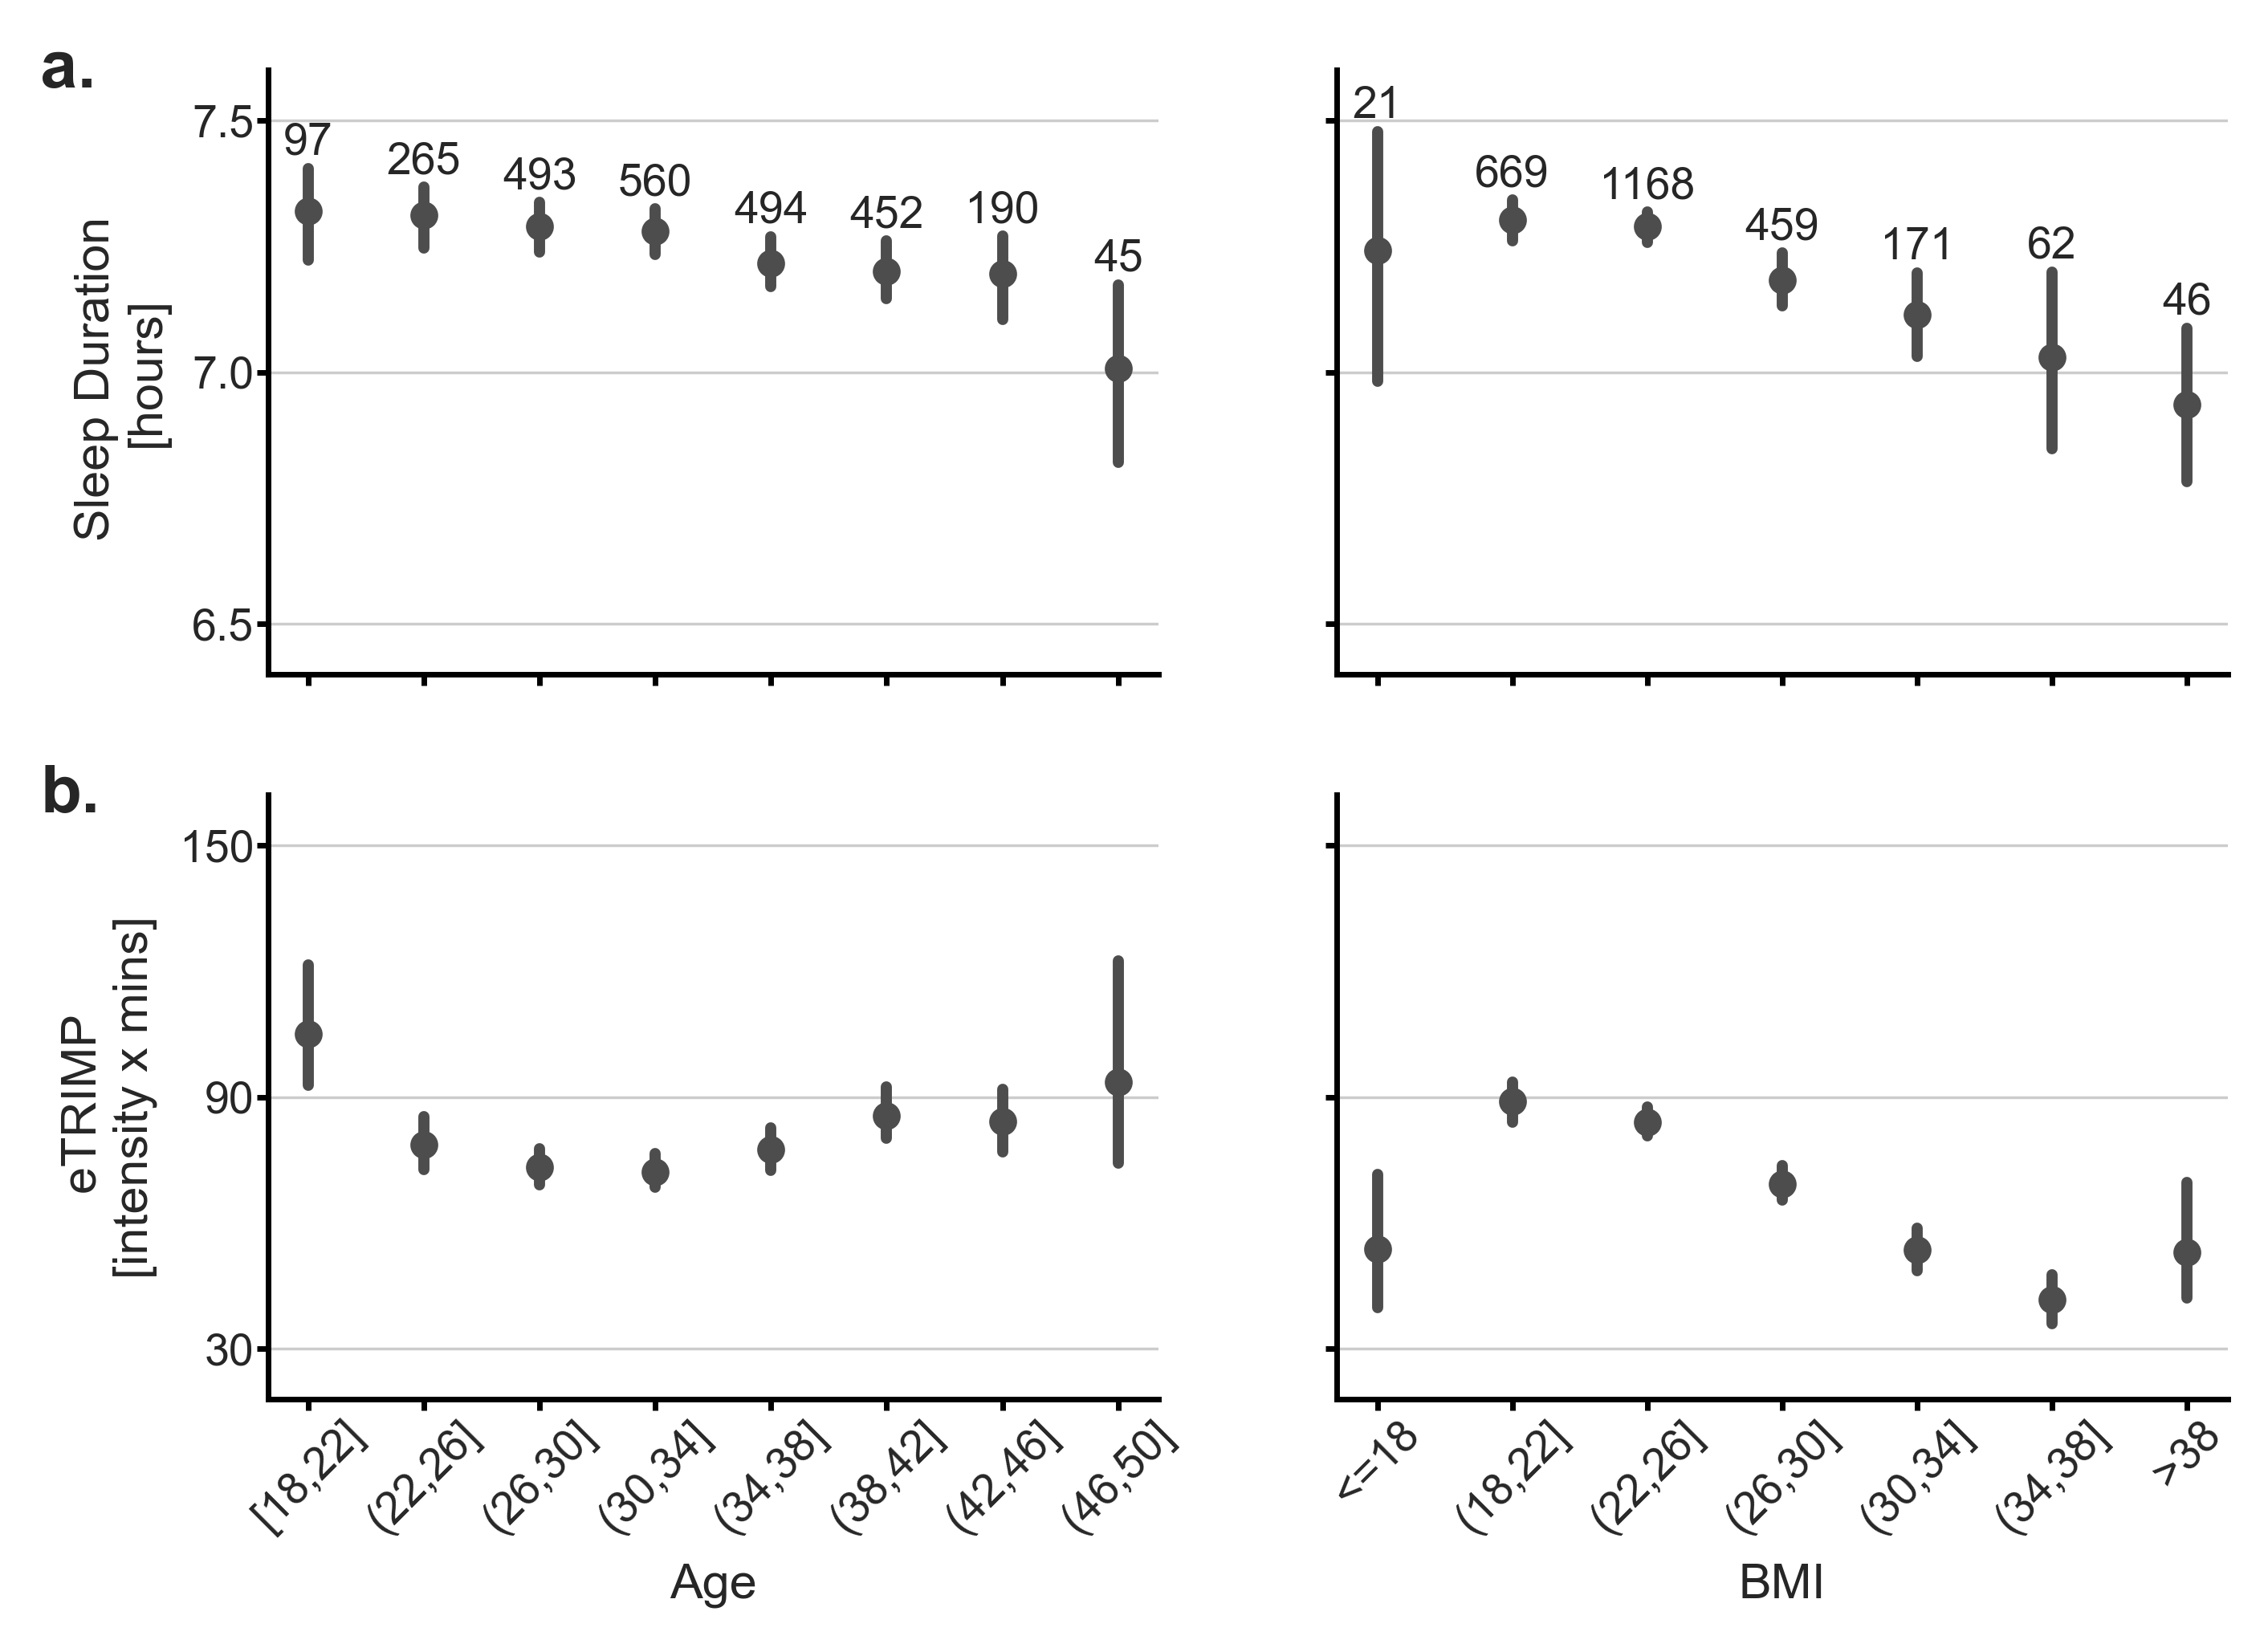

In [8]:
cla.behav_x_age_bmi_plots(save_fig=False)
plt.show()